# FIRST PROBLEM

In [1]:
import pandas as pd

df = pd.read_csv('lab1og/churn.txt')
print(df.head())

  State  Account Length  Area Code     Phone Int'l Plan VMail Plan  \
0    KS             128        415  382-4657         no        yes   
1    OH             107        415  371-7191         no        yes   
2    NJ             137        415  358-1921         no         no   
3    OH              84        408  375-9999        yes         no   
4    OK              75        415  330-6626        yes         no   

   VMail Message  Day Mins  Day Calls  Day Charge  ...  Eve Calls  Eve Charge  \
0             25     265.1        110       45.07  ...         99       16.78   
1             26     161.6        123       27.47  ...        103       16.62   
2              0     243.4        114       41.38  ...        110       10.30   
3              0     299.4         71       50.90  ...         88        5.26   
4              0     166.7        113       28.34  ...        122       12.61   

   Night Mins  Night Calls  Night Charge  Intl Mins  Intl Calls  Intl Charge  \
0       244.

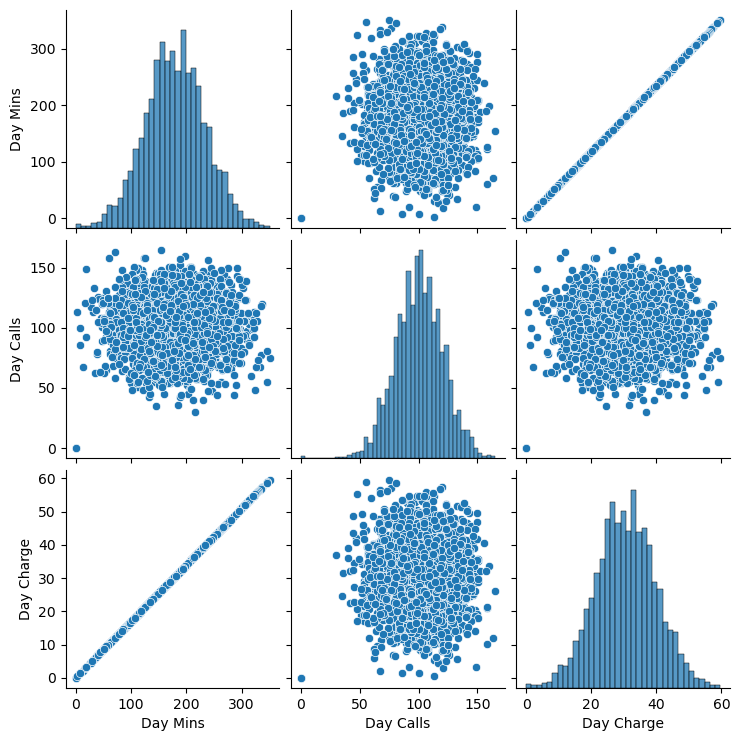

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

data_to_plot = df[["Day Mins", "Day Calls", "Day Charge"]]
sns.pairplot(data_to_plot)

plt.show()

plt.show()

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

x = df[['Day Mins']]
y = df[["Day Charge"]]
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)
# Predict on test data
y_pred = model.predict(X_test)
# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")
print(f"Intercept: {model.intercept_}")
print(f"Coefficient (Day mins): {model.coef_[0]}")


Mean Squared Error: 0.00
R² Score: 1.00
Intercept: [0.00056847]
Coefficient (Day mins): [0.16999966]


In [61]:
x = df[['Intl Mins']]
y = df[["Intl Charge"]]
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)
# Predict on test data
y_pred = model.predict(X_test)
# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")
print(f"Intercept: {model.intercept_}")
print(f"Coefficient (Intl Mins): {model.coef_[0]}")

Mean Squared Error: 0.00
R² Score: 1.00
Intercept: [0.00056688]
Coefficient (Intl Mins): [0.26999442]


y(day charge) = a0(intercept) + a1(coefficient = cos per minute of a call) * x1(day mins)

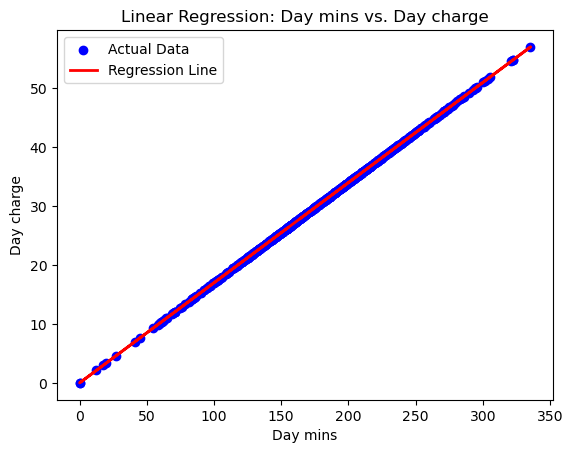

In [15]:
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test, color="blue", label="Actual Data")
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Regression Line")

plt.xlabel("Day mins")
plt.ylabel("Day charge")
plt.title("Linear Regression: Day mins vs. Day charge")
plt.legend()
plt.show()


# SECOND PROBLEM

In [17]:
df2 = pd.read_csv('lab1og/CarsWOO.txt')
print(df2.head())

    mpg  cylinders  cubicinches   hp  weightlbs  time-to-60  year brand
0  14.0          8          350  165     4209.0          12  1972   US.
1  17.0          8          302  140     3449.0          11  1971   US.
2  15.0          8          400  150     3761.0          10  1971   US.
3  30.5          4           98   63     2051.0          17  1978   US.
4  23.0          8          350  125     3900.0          17  1980   US.


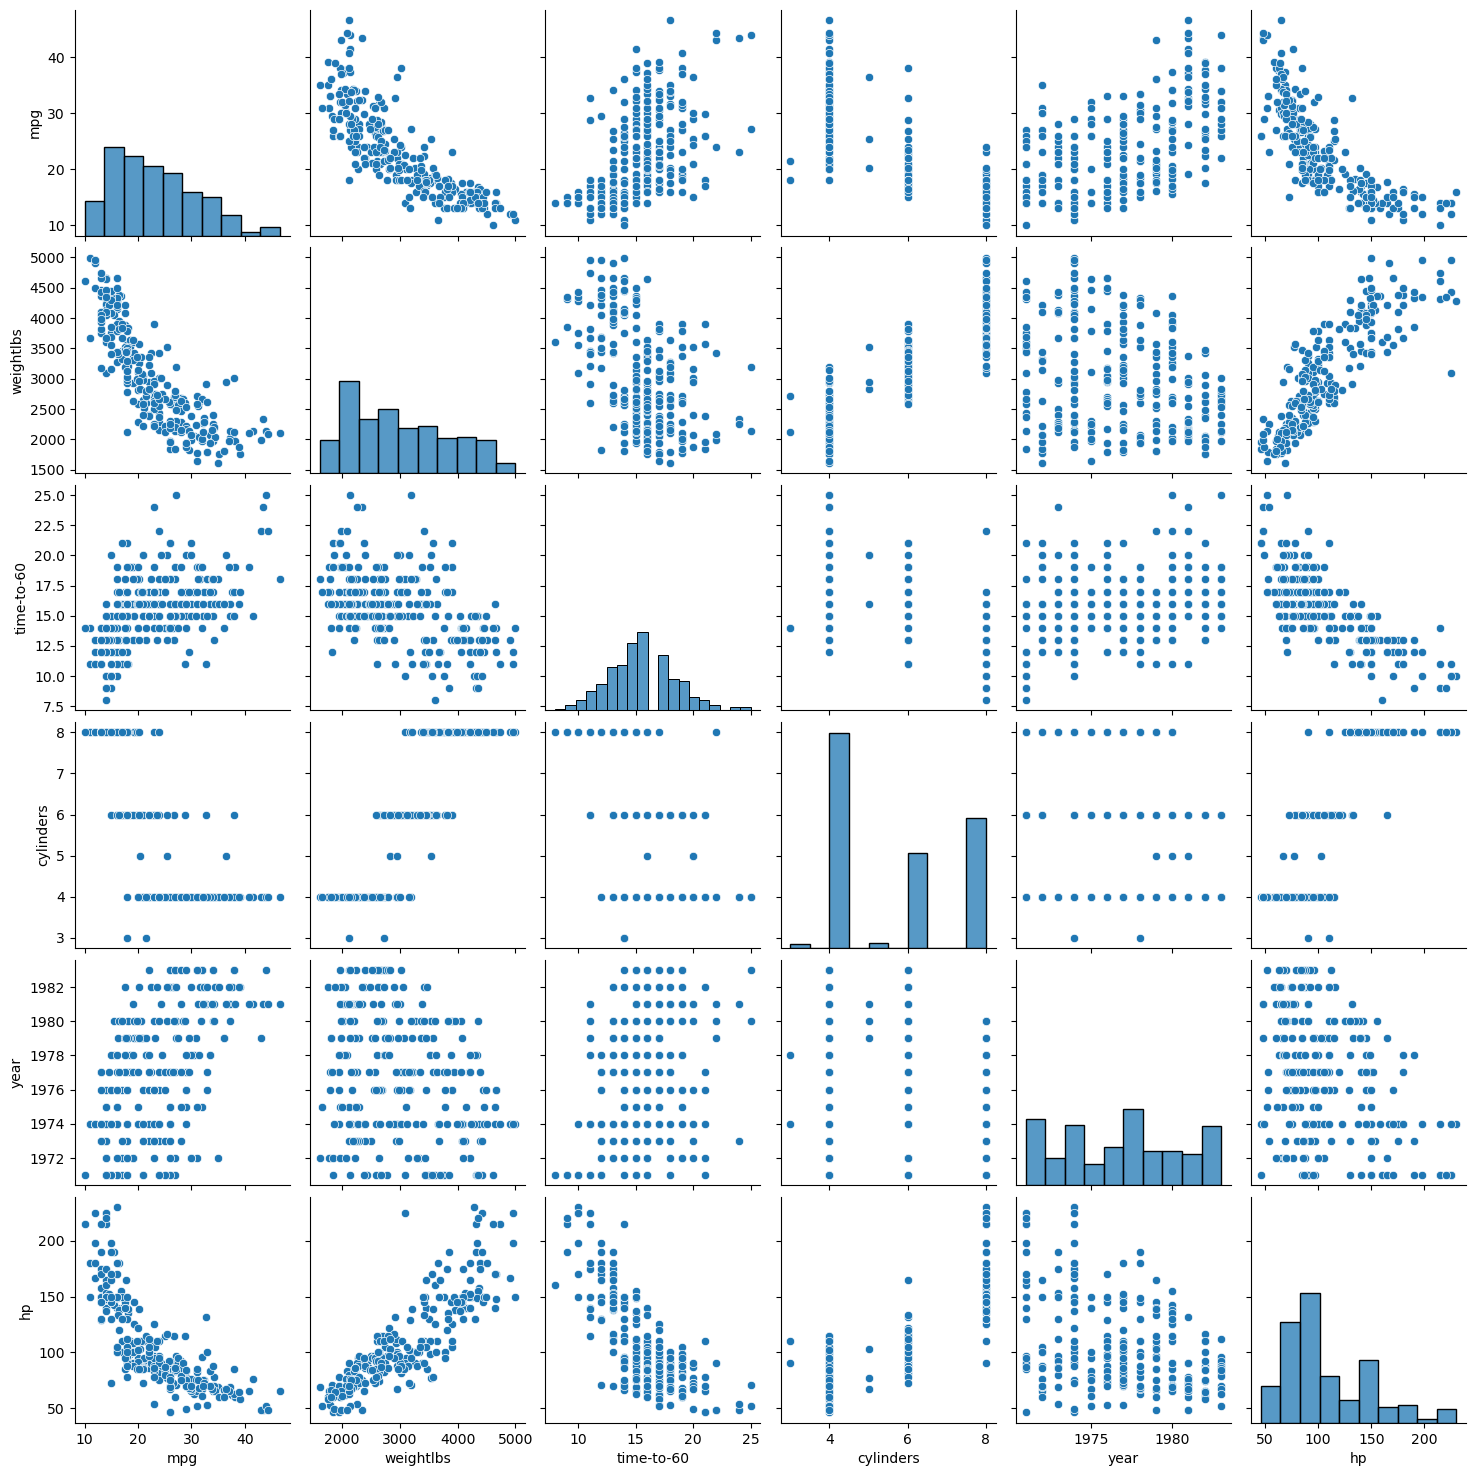

In [63]:
data_to_plot = df2[["mpg", "weightlbs", "time-to-60", "cylinders", "year", "hp"]]
sns.pairplot(data_to_plot)

plt.show()

plt.show()

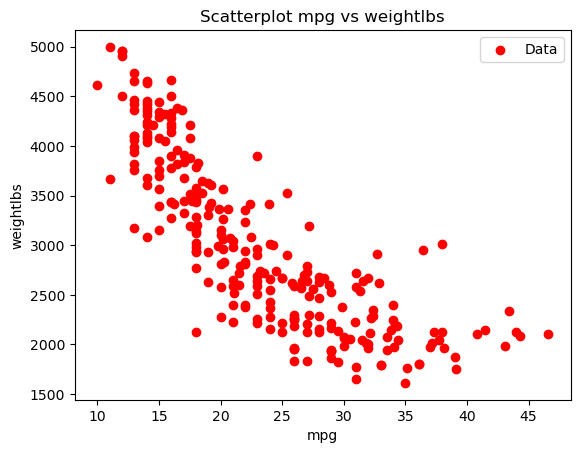

In [19]:
plt.scatter(df2["mpg"], df2["weightlbs"], color="red", label="Data")

plt.xlabel("mpg")
plt.ylabel("weightlbs")
plt.title("Scatterplot mpg vs weightlbs")
plt.legend()
plt.show()

In [57]:
data = df2[df2["year"] == 1980]
print(data.head())
x = data[["mpg"]].values
y = data["weightlbs"].values
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)
# Predict on test data
y_pred = model.predict(X_test)
# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")
print(f"Intercept: {model.intercept_}")
print(f"Coefficient (mpg): {model.coef_[0]}")

     mpg  cylinders  cubicinches   hp  weightlbs  time-to-60  year    brand
4   23.0          8          350  125     3900.0          17  1980      US.
7   25.4          5          183   77     3530.0          20  1980  Europe.
14  16.9          8          350  155     4360.0          15  1980      US.
15  31.8          4           85   65     2020.0          19  1980   Japan.
22  15.5          8          351  142     4054.0          14  1980      US.
Mean Squared Error: 272454.78
R² Score: -1.59
Intercept: 5651.579994769289
Coefficient (mpg): -103.58105402675996


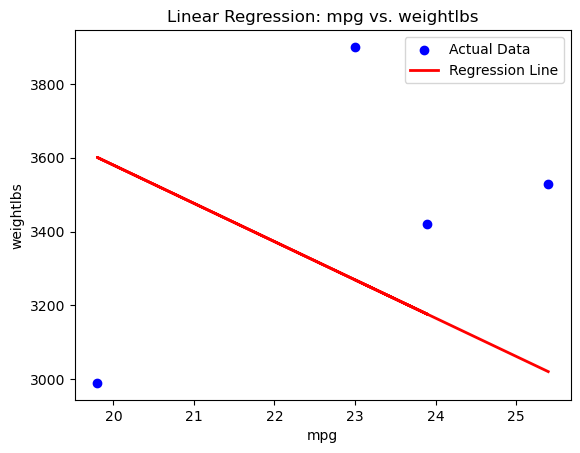

In [58]:
plt.scatter(X_test, y_test, color="blue", label="Actual Data")
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Regression Line")

plt.xlabel("mpg")
plt.ylabel("weightlbs")
plt.title("Linear Regression: mpg vs. weightlbs")
plt.legend()
plt.show()

In [59]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(x)  # Adds x² column

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)
print(X_poly.shape)
# Train polynomial regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Get coefficients

print(f"Intercept (a0): {model.intercept_}")
print(f"Coefficient for mpg (a1): {model.coef_[1]}")
print(f"Coefficient for mpg^2 (a2): {model.coef_[2]}")

(20, 3)
Intercept (a0): 7002.101204456627
Coefficient for mpg (a1): -218.14505964206612
Coefficient for mpg^2 (a2): 2.237742981029084


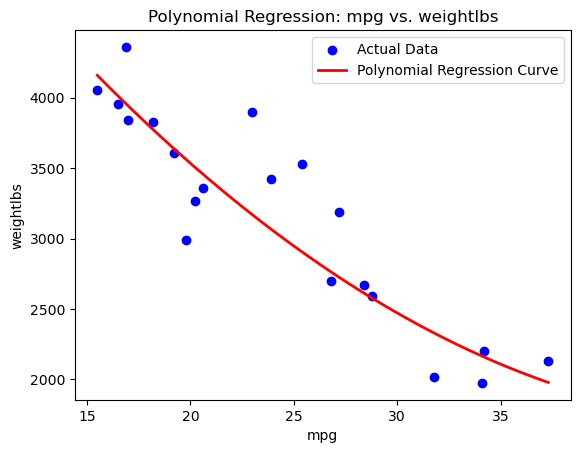

In [60]:
import numpy as np
plt.scatter(x, y, color="blue", label="Actual Data")

# Generate a smooth curve for polynomial regression
X_range = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
X_range_poly = poly.transform(X_range)
y_range_pred = model.predict(X_range_poly)

# Plot regression curve
plt.plot(X_range, y_range_pred, color="red", linewidth=2, label="Polynomial Regression Curve")

plt.xlabel("mpg")
plt.ylabel("weightlbs")
plt.title("Polynomial Regression: mpg vs. weightlbs")
plt.legend()
plt.show()

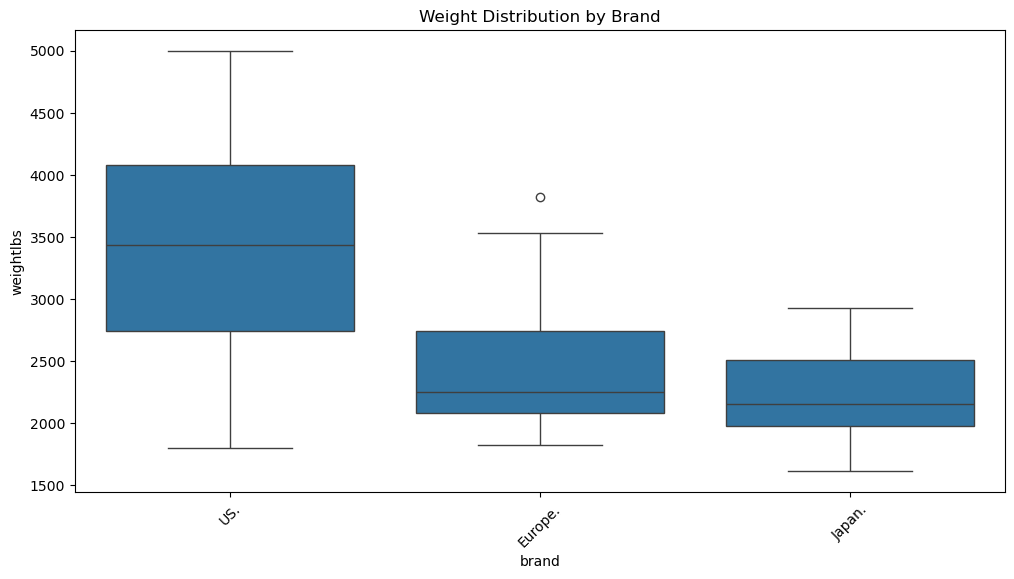

In [40]:
from scipy.stats import spearmanr
plt.figure(figsize=(12, 6))
sns.boxplot(x="brand", y="weightlbs", data=df2)
plt.xticks(rotation=45)  # Rotate labels if needed
plt.title("Weight Distribution by Brand")
plt.show()

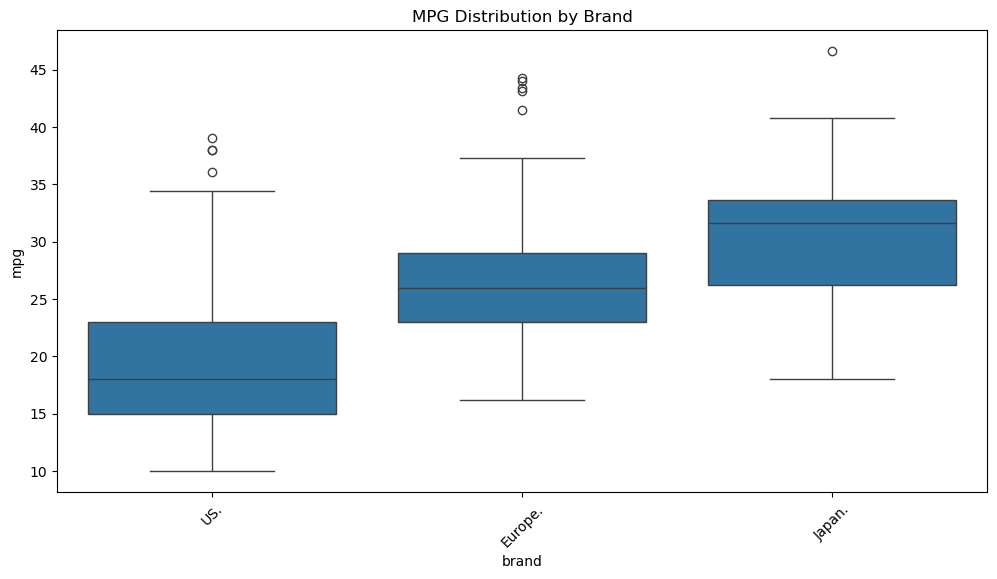

In [41]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="brand", y="mpg", data=df2)
plt.xticks(rotation=45)
plt.title("MPG Distribution by Brand")
plt.show()

In [46]:
american_cars = df2[df2["brand"] == "US."]
japanese_cars = df2[df2["brand"] == "Japan."]
european_cars = df2[df2["brand"] == "Europe."]

print(f"American cars: {len(american_cars)}")
print(f"Japanese cars: {len(japanese_cars)}")
print(f"European cars: {len(european_cars)}")

def rank_correlation(data, label):
    correlation, p_value = spearmanr(data["mpg"], data["weightlbs"])
    print(f"{label} Cars - Spearman Correlation: {correlation}, p-value: {p_value}")

# Compute correlation for each group
rank_correlation(american_cars, "American")
rank_correlation(japanese_cars, "Japanese")
rank_correlation(european_cars, "European")


American cars: 161
Japanese cars: 51
European cars: 47
American Cars - Spearman Correlation: -0.8659974697240509, p-value: 1.0117171410047066e-49
Japanese Cars - Spearman Correlation: -0.5945273253081325, p-value: 4.222558589462105e-06
European Cars - Spearman Correlation: -0.6496441803981186, p-value: 7.782365946620888e-07


Negative correlation suggests heavier cars tend to have lower mpg

# 3rd PROBLEM

In [49]:
df3 = pd.read_csv("lab1og/cadata.csv", sep=';')
print(df3.head())

   median house value  median income  housing median age  total rooms  \
0            452600.0         8.3252                41.0        880.0   
1            358500.0         8.3014                21.0       7099.0   
2            352100.0         7.2574                52.0       1467.0   
3            341300.0         5.6431                52.0       1274.0   
4            342200.0         3.8462                52.0       1627.0   

   total bedrooms  population  households  latitude  longitude  
0           129.0       322.0       126.0     37.88    -122.23  
1          1106.0      2401.0      1138.0     37.86    -122.22  
2           190.0       496.0       177.0     37.85    -122.24  
3           235.0       558.0       219.0     37.85    -122.25  
4           280.0       565.0       259.0     37.85    -122.25  


In [50]:
#Numeric binning:
bins = [0, 140000, 300000, float('inf')]
labels = ['inexpensive houses', 'expensive houses', 'manors']
df3['median house value'] = pd.cut(df3['median house value'], bins=bins, labels=labels, include_lowest=True)
print(df3[['median house value']].head())

  median house value
0             manors
1             manors
2             manors
3             manors
4             manors


In [51]:
value_count = df3[['median house value']].value_counts()
print(value_count)

median house value
expensive houses      10044
inexpensive houses     6760
manors                 3836
Name: count, dtype: int64


In [52]:
#auto binning using quantiles
df_auto = pd.read_csv("lab1og/cadata.csv", sep=';')
quantiles = [0.0, 0.25, 0.5, 0.75, 1.0]
df_auto['median house value'] = pd.qcut(df_auto['median house value'], q=quantiles, duplicates='drop')
print(df_auto[['median house value']].head())

     median house value
0  (264725.0, 500001.0]
1  (264725.0, 500001.0]
2  (264725.0, 500001.0]
3  (264725.0, 500001.0]
4  (264725.0, 500001.0]


In [53]:
auto_value_counts = df_auto[['median house value']].value_counts()
print(auto_value_counts)

median house value   
(14998.999, 119600.0]    5162
(119600.0, 179700.0]     5161
(264725.0, 500001.0]     5160
(179700.0, 264725.0]     5157
Name: count, dtype: int64
